# 01 LILAC SH5 Data Collection: Forward Dynamics

Records demonstrations by applying IK targets through MuJoCo position actuators and stepping dynamics.

In [1]:
%run ../../../ri_motion_v5_package/init_scripts/init_ipython_setup.py
%run ../../../ri_motion_v5_package/init_scripts/init_qt.py
%run ../package/init_project.py

from pathlib import Path

from ri_motion_v5_package.init_scripts.init_ipython_setup import *
from ri_motion_v5_package.init_scripts.init_qt import *
from ri_motion_v5_package.mujoco_sim import *
from ri_motion_v5_package.kinematics import *
from ri_motion_v5_package.utility import *
from ri_motion_v5_package.vader5 import *


Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.
[qt] package initialized.

[LILAC_project] initialized.
Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.
[qt] package initialized.
pygame 2.6.1 (SDL 2.28.4, Python 3.10.20)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
# Demo / language parameters
TASK_NAME = "cup_to_bowl"
EPISODE_TYPE = "instruction"
INSTRUCTION = "Pick up the cup and pour water into the bowl"
OBJECT_SITE_NAMES = DEFAULT_TASK_OBJECT_SITE_NAMES

USE_LILAC_MODEL_IF_AVAILABLE = False  # Keep direct control while recording demonstration data.
VADER5_DEADZONE = 0.15
VADER5_TRIGGER_CENTER = 1.0
RESET_OBJECT_BODY_NAMES = list(DEFAULT_RESET_OBJECT_BODY_NAMES)


In [3]:
# Scene
env = MuJoCoParser(rel_xml_path=SCENE_XML, verbose=False)

ctrl_group = group_by_prefix(
    items       = env.ctrl_names,
    prefix_dict = {
        "lift" : "lift",
        "arm"  : ["arm_l", "arm_r"],
        "hand" : ["finger_l", "finger_r"],
    },
)
ctrl_names_fd = ctrl_group["lift"] + ctrl_group["arm"] + ctrl_group["hand"]
env.restore_ctrl_info(ctrl_names=ctrl_names_fd, verbose=False)
env.set_ctrl_info(ctrl_names=ctrl_group["lift"], p_gain=1e6, d_gain=100.0, force=2e5, verbose=False)
env.set_ctrl_info(ctrl_names=ctrl_group["arm"], p_gain=3000.0, d_gain=100.0, force=200.0, verbose=False)
env.set_ctrl_info(ctrl_names=ctrl_group["hand"], p_gain=100.0, d_gain=10.0, force=None, verbose=False)
SIM_NSTEP = max(1, int(round(1.0 / (30.0 * env.dt))))


MuJoCo model loaded from [/Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/notebook/xml/scene_ffw_sh5_lilac.xml].


In [4]:
# LILAC runtime objects. Keep collection mode simple and explicit.
RUNTIME_COMMAND_PATH = RUNTIME_LANGUAGE_COMMAND

runtime = build_lilac_runtime(
    instruction            = INSTRUCTION,
    language_dataset_path  = CANONICAL_LANGUAGE_DATASET,
    run_dir                = RUN_DIR,
    command_path           = RUNTIME_COMMAND_PATH,
    use_model_if_available = USE_LILAC_MODEL_IF_AVAILABLE,
    direct_mode_label      = "direct Vader5 FD",
    action_pos_scale       = 0.025,
    action_rot_scale       = 15.0 * D2R,
)
controller = runtime.controller
command_source = runtime.command_source
use_lilac_model = runtime.use_lilac_model

print("Control mode:", "LILAC latent action" if use_lilac_model else "direct Vader5 FD")
print("Append commands to %s, e.g. `push pour water`, `push up!`, or `pop`." % RUNTIME_COMMAND_PATH)


[LILAC] collection mode: direct Vader5 FD
Control mode: direct Vader5 FD
Append commands to /Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/data/runtime_language_command.txt, e.g. `push pour water`, `push up!`, or `pop`.


In [5]:
# Reset environment and initialize viewer
env.reset()
env.init_viewer(
    title     = "LILAC SH5 collection 01 - forward dynamics",
    x_offset  = 0.22,
    width     = 1.0,
    height    = 1.0,
    fontscale = 200,)

env.viewer.set_cam_info(-54.03, 1.35, -34.22, np.array([ 0.4 , -0.16,  1.12]))
env.viewer.set_transparency(transparent=True)
env.viewer.set_geomgroup(group_2=True, group_3=False)
env.viewer.set_sitegroup(group_0=False)

env.set_p("base_link", "body", (0, 0, 0.01))
env.forward(q=[-0.1], joint_names=["lift_joint"])
env.forward(
    q=[1.12, -0.14, -0.15, -2.48, -0.18, -0.22, -0.02],
    joint_names=[
        "arm_r_joint1", "arm_r_joint2", "arm_r_joint3", "arm_r_joint4",
        "arm_r_joint5", "arm_r_joint6", "arm_r_joint7",
    ],
)
env.forward(
    q=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    joint_names=[
        "arm_l_joint1", "arm_l_joint2", "arm_l_joint3", "arm_l_joint4",
        "arm_l_joint5", "arm_l_joint6", "arm_l_joint7",
    ],
)

object_state = get_task_object_state(env, site_names=OBJECT_SITE_NAMES)
reset_object_body_names = [name for name in RESET_OBJECT_BODY_NAMES if name in env.body_names]

def reset_task_objects():
    reset_freejoint_bodies_to_xml_pose(env, reset_object_body_names)

vader5 = build_vader5_handler(joystick_idx=0, verbose=True)
js = vader5.js
state = vader5.get_state(update_first=True)
trigger_idle = [state.get("trigger_top_left"), state.get("trigger_top_right")]
if all(v is not None for v in trigger_idle):
    VADER5_TRIGGER_CENTER = float(np.mean(trigger_idle))
print("[vader5] trigger center:", VADER5_TRIGGER_CENTER)

use_r_joint_names = get_right_arm_joint_names(env)
right_hand_joint_names = get_right_finger_joint_names()
joint_names_all = list(use_r_joint_names) + right_hand_joint_names
idxs_ctrl_arm = env.get_ctrl_idxs_attached_joints(use_r_joint_names)
idxs_ctrl_hand = env.get_ctrl_idxs_attached_joints(right_hand_joint_names)
ctrl_vals = env.get_ctrl_qpos(ctrl_names=env.ctrl_names)
ik_solver = build_right_arm_ik_solver(env, use_r_joint_names=use_r_joint_names)
T_rpalm_init = get_right_palm_T(env).copy()
T_rpalm_trgt = T_rpalm_init.copy()
right_grasp_init = 0.0
right_grasp = right_grasp_init
q_arm_cmd = env.get_qpos(joint_names=use_r_joint_names).copy()
q_hand_cmd = get_right_finger_qpos(right_grasp)
env.forward(q=q_arm_cmd, joint_names=use_r_joint_names)
env.forward(q=q_hand_cmd, joint_names=right_hand_joint_names)
ctrl_vals[idxs_ctrl_arm] = q_arm_cmd
ctrl_vals[idxs_ctrl_hand] = q_hand_cmd
env.set_zero_qvel()
state = vader5.get_state(update_first=False)

z = np.zeros(2)
lilac_info = make_lilac_info(controller)


name:[Nintendo Switch Pro Controller]
axes:[6]
buttons:[20]
[vader5] trigger center: 0.0
MuJoCo model loaded from [/Users/junha/workspace/RILAB/lab_semina/project/LILAC_project/notebook/xml/scene_ffw_sh5_lilac.xml].


In [6]:
# Dataset recorder. Press B to start/stop recording. Press A to cancel active recording and return home.
record_on = False
recorder = None
saved_recordings = []
DATASET_EPISODE_DIR = collection_episode_dir("../data", TASK_NAME, EPISODE_TYPE)
INITIAL_EPISODE_COUNT = count_collection_episodes(DATASET_EPISODE_DIR)
print("[dataset]", DATASET_EPISODE_DIR, "existing episodes:", INITIAL_EPISODE_COUNT)

def make_recorder(episode_type=None):
    return make_collection_recorder(
        data_dir      = "../data",
        task_name     = TASK_NAME,
        instruction   = INSTRUCTION,
        episode_type  = EPISODE_TYPE if episode_type is None else episode_type,
        joint_names   = use_r_joint_names,
        object_state  = object_state,
    )

def stop_and_save_recorder():
    global recorder, record_on
    save_collection_recorder(recorder, saved_recordings)
    recorder = None
    record_on = False

def cancel_recorder():
    global recorder, record_on
    n_frames = 0 if recorder is None else len(recorder.frames)
    print("[dataset] canceled recording; discarded %d frames" % n_frames)
    recorder = None
    record_on = False


[dataset] ../data/cup_to_bowl/instruction existing episodes: 15


[Vader5] Initialized with [30.0]HZ. MAX_SEC:[inf]sec.
[Render] Initialized with [30.0]HZ. MAX_SEC:[inf]sec.
[Vader5] Start ([30.0]HZ. MAX_SEC:[inf]sec).
[Render] Start ([30.0]HZ. MAX_SEC:[inf]sec).
[language] ('instruction', 'Pick up the cup and pour water into the bowl.')
[Render][1] run delayed! T:[33.3]ms run:[285.4]ms]
[Vader5][2][0.3s] delayed! T:[33.3]ms interval:[301.6]ms prev_run:[15.7]ms.
[Render][2][0.3s] delayed! T:[33.3]ms interval:[298.4]ms prev_run:[285.4]ms.
[Render][2] run delayed! T:[33.3]ms run:[67.4]ms]
[Vader5][3][0.4s] delayed! T:[33.3]ms interval:[80.1]ms prev_run:[12.5]ms.
[Render][3][0.4s] delayed! T:[33.3]ms interval:[80.9]ms prev_run:[67.4]ms.
[Render][3] run delayed! T:[33.3]ms run:[45.1]ms]
[Vader5][4][0.4s] delayed! T:[33.3]ms interval:[58.5]ms prev_run:[13.3]ms.
[Render][4][0.5s] delayed! T:[33.3]ms interval:[55.8]ms prev_run:[45.1]ms.
[Render][4] run delayed! T:[33.3]ms run:[46.0]ms]
[Vader5][5][0.5s] delayed! T:[33.3]ms interval:[56.6]ms prev_run:[10.5]m

2026-06-06 17:19:24.660 python[37229:346992] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


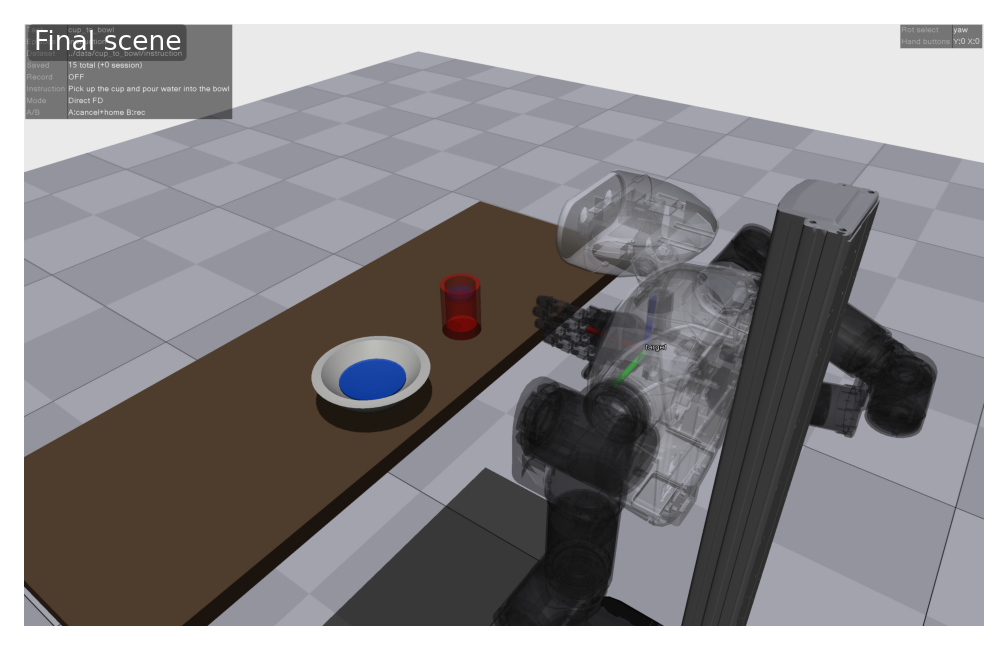

In [7]:
tmr_vader5 = SimpleTimer(name="Vader5", Hz=30, verbose=True)
tmr_render = SimpleTimer(name="Render", Hz=30, verbose=True)
tmr_language = SimpleTimer(name="LanguageCommand", Hz=5, verbose=False)

tmr_vader5.start()
tmr_render.start()
tmr_language.start()
env.reset_wall_time()

prev_button_a = 0
prev_button_b = 0
cmd = {"state": state, "rot_dir": vader5.rot_dir, "ddeg": 0.0}

try:
    while env.is_viewer_alive():
        env.increase_wall_time()
        did_control_tick = False

        if tmr_language.do_run():
            events = command_source.poll(controller)
            for event in events:
                print("[language]", event)
            tmr_language.end()

        if tmr_vader5.do_run():
            pose_before = T_to_pose6(T_rpalm_trgt)
            object_state = get_task_object_state(env, site_names=OBJECT_SITE_NAMES)

            if use_lilac_model:
                state = vader5.get_state(update_first=True)
                z = vader5_state_to_latent_z(state, th=VADER5_DEADZONE)
                q_arm_curr = env.get_qpos(joint_names=use_r_joint_names)
                ee_pose_curr = T_to_pose6(get_right_palm_T(env))
                state_vec = np.concatenate([q_arm_curr, ee_pose_curr, object_state])
                T_rpalm_trgt, lilac_info = controller.update_target(
                    T_curr = T_rpalm_trgt,
                    state  = state_vec,
                    z      = z,
                )
            else:
                T_rpalm_trgt, cmd = vader5.update_T_trgt(
                    T_curr       = T_rpalm_trgt,
                    dt           = tmr_vader5.dt,
                    update_first = True,
                    th           = VADER5_DEADZONE,
                    xyz_scale    = 0.25,
                    rpy_scale    = 45.0,
                    trigger_center = VADER5_TRIGGER_CENTER,
                    return_cmd   = True,
                )
                state = cmd["state"]
                z = vader5_state_to_latent_z(state, th=VADER5_DEADZONE)
                lilac_info = make_lilac_info(
                    controller = controller,
                    source     = "direct_vader5_mapping",
                    z          = z,
                    alpha      = controller.alpha_labeler(controller.active_utterance()),
                )

            button_a = int(js.get_button(VADER5_BUTTON_A))
            button_b = int(js.get_button(VADER5_BUTTON_B))
            a_pressed = button_a == 1 and prev_button_a == 0
            b_pressed = button_b == 1 and prev_button_b == 0
            prev_button_a = button_a
            prev_button_b = button_b

            if b_pressed:
                if record_on:
                    stop_and_save_recorder()
                    print("[record] OFF")
                else:
                    recorder = make_recorder()
                    record_on = True
                    print("[record] ON")

            if a_pressed:
                if record_on:
                    cancel_recorder()
                    print("[record] CANCELED")
                T_rpalm_trgt = T_rpalm_init.copy()
                right_grasp = right_grasp_init
                q_hand_cmd = get_right_finger_qpos(right_grasp)
                ctrl_vals[idxs_ctrl_hand] = q_hand_cmd
                reset_task_objects()
                object_state = get_task_object_state(env, site_names=OBJECT_SITE_NAMES)
                vader5.reset_motion_memory(rot_dir="yaw")
                print("[home] returned to initial right-palm target and task objects")

            action_delta = pose6_delta(pose_before, T_to_pose6(T_rpalm_trgt))
            lilac_info["action"] = action_delta

            q_r_best, ik_info = solve_right_palm_ik(
                env               = env,
                ik_solver         = ik_solver,
                T_rpalm_trgt      = T_rpalm_trgt,
                use_r_joint_names = use_r_joint_names,
            )
            q_arm_cmd = q_r_best.copy()
            ctrl_vals[idxs_ctrl_arm] = q_arm_cmd

            right_grasp = update_right_finger_command(
                vader5      = vader5,
                right_grasp = right_grasp,
                dt          = tmr_vader5.dt,
                grip_speed  = 2.0,
            )
            q_hand_cmd = get_right_finger_qpos(right_grasp)
            ctrl_vals[idxs_ctrl_hand] = q_hand_cmd

            env.compensate_gravity(root_body_names=["base_link"], on=True)
            env.step(ctrl=ctrl_vals, nstep=SIM_NSTEP)
            qpos_used_all = np.concatenate([
                env.get_qpos(joint_names=use_r_joint_names),
                env.get_qpos(joint_names=right_hand_joint_names),
            ])
            contact_info = env.get_contact_info(forward=False)
            contact_on = contact_info["n_contact"] > 0

            if record_on and recorder is not None:
                recorder.append(
                    q_arm            = env.get_qpos(joint_names=use_r_joint_names),
                    q_hand           = env.get_qpos(joint_names=right_hand_joint_names),
                    q_all            = qpos_used_all,
                    T_ee             = get_right_palm_T(env),
                    action_ee_delta  = lilac_info.get("action", np.zeros(6)),
                    latent_z         = z,
                    vader5_state     = state,
                    object_state     = object_state,
                    correction_stack = lilac_info.get("language_stack", controller.language_stack.as_dict()),
                    active_utterance = lilac_info.get("utterance", controller.active_utterance()),
                    alpha            = lilac_info.get("alpha", np.nan),
                    right_grasp      = right_grasp,
                    ik_err           = ik_info["ik_err_best"],
                    contact_on       = contact_on,
                    extra            = {"source": lilac_info.get("source", "unknown")},)

            tmr_vader5.end()
            did_control_tick = True

        if tmr_render.do_run():
            active = str(lilac_info.get("utterance", controller.active_utterance()))[:42]
            collection_rows = make_collection_overlay_rows(
                data_dir              = "../data",
                task_name             = TASK_NAME,
                episode_type          = EPISODE_TYPE,
                instruction           = INSTRUCTION,
                initial_episode_count = INITIAL_EPISODE_COUNT,
                saved_recordings      = saved_recordings,
                record_on             = record_on,
                recorder              = recorder,
            )

            env.plot_T(T=T_rpalm_trgt, axis_len=0.12, axis_width=0.006, label="target")
            for overlay_label, overlay_text in collection_rows:
                env.viewer_text_overlay(overlay_label, overlay_text, loc="top left")
            env.viewer_text_overlay("Mode", "LILAC" if use_lilac_model else "Direct FD", loc="top left")
            env.viewer_text_overlay("A/B", "A:cancel+home B:rec", loc="top left")
            env.viewer_text_overlay("Rot select", "%s" % (vader5.rot_dir), loc="top right")
            env.viewer_text_overlay("Hand buttons", "Y:%d X:%d" % (js.get_button(3), js.get_button(2)), loc="top right")
            env.render()
            tmr_render.end()
except KeyboardInterrupt:
    print("Interrupted.")
finally:
    if record_on:
        stop_and_save_recorder()
    env.close_viewer()
    vader5.close()
    imshow(env.final_rgb_img, title="Final scene", title_fs=8)


In [8]:
print(env.get_qpos(joint_names=use_r_joint_names))


[ 1.12 -0.14 -0.15 -2.48 -0.18 -0.22 -0.02]


In [ ]:
print(env.viewer.get_cam_info())


(-54.03, 1.35, -34.22, array([ 0.4 , -0.16,  1.12]))


: 